In [1]:
import cv2
import pickle

recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("face_recognizer.yml")

with open("labels.pickle", "rb") as f:
    label_map = pickle.load(f)
id_to_name = {v: k for k, v in label_map.items()}

face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
print("Model and labels loaded:", id_to_name)

Model and labels loaded: {0: 'Atul Singh'}


In [2]:
# from time import sleep
# from pynq.overlays.base import BaseOverlay
# base = BaseOverlay("base.bit")
# for led in base.led
import cv2
import csv
import os
from datetime import datetime

CONFIDENCE_THRESHOLD = 70

def mark_attendance(name):
    today = datetime.now().strftime("%Y-%m-%d")
    file_path = f"{today}.csv"

    # check if already marked today
    if os.path.exists(file_path):
        with open(file_path, "r") as f:
            for row in csv.reader(f):
                if row and row[0] == name:
                    return False

    # write header if file is new
    file_exists = os.path.exists(file_path)
    with open(file_path, "a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(["Name", "Time"])
        writer.writerow([name, datetime.now().strftime("%H:%M:%S")])
    return True

# connect to laptop's camera stream
cap = cv2.VideoCapture("http://192.168.2.1:5000/video")

print("Recognizing... this will run for 30 frames then stop.")

for i in range(30):  # process 30 frames then stop (Jupyter has no easy 'q to quit')
    ret, frame = cap.read()
    if not ret:
        print("Failed to read frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    for (x, y, w, h) in faces:
        face_crop = gray[y:y+h, x:x+w]
        label_id, confidence = recognizer.predict(face_crop)

        if confidence < CONFIDENCE_THRESHOLD:
            name = id_to_name.get(label_id, "Unknown")
        else:
            name = "Unknown"

        if name != "Unknown":
            marked = mark_attendance(name)
            if marked:
                print(f"Attendance marked: {name}")

cap.release()
print("Done processing frames.")

Recognizing... this will run for 30 frames then stop.
Done processing frames.


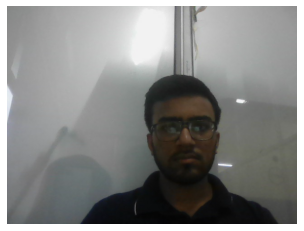

In [3]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("http://192.168.2.1:5000/video")
ret, frame = cap.read()
cap.release()

if ret:
    # convert BGR (OpenCV) to RGB (matplotlib) before showing
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()
else:
    print("Failed to capture frame")

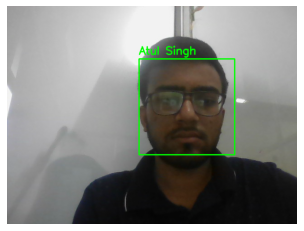

Live view stopped.


In [4]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

cap = cv2.VideoCapture("http://192.168.2.1:5000/video")

print("Starting live view... this runs for 50 frames (~15-20 sec). Interrupt kernel (■ button) to stop early.")

for i in range(50):
    ret, frame = cap.read()
    if not ret:
        print("Failed to read frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    for (x, y, w, h) in faces:
        face_crop = gray[y:y+h, x:x+w]
        label_id, confidence = recognizer.predict(face_crop)

        if confidence < CONFIDENCE_THRESHOLD:
            name = id_to_name.get(label_id, "Unknown")
        else:
            name = "Unknown"

        # draw box + name on the frame
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(frame, name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        if name != "Unknown":
            marked = mark_attendance(name)
            if marked:
                print(f"Attendance marked: {name}")

    # refresh the displayed image in place (looks like live video)
    clear_output(wait=True)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

cap.release()
print("Live view stopped.")

In [5]:
import requests
print("requests available")

requests available


In [6]:
import requests

LAPTOP_IP = "192.168.2.1"  # laptop's Ethernet IP

def send_result(name, box):
    try:
        requests.post(
            f"http://{LAPTOP_IP}:5000/update_result",
            json={"name": name, "box": list(box)},
            timeout=1
        )
    except Exception as e:
        print("Failed to send result:", e)

In [7]:
cap = cv2.VideoCapture(f"http://{LAPTOP_IP}:5000/video")

print("Running recognition and sending results to laptop... 100 frames (~30 sec).")

for i in range(100):
    ret, frame = cap.read()
    if not ret:
        print("Failed to read frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    for (x, y, w, h) in faces:
        face_crop = gray[y:y+h, x:x+w]
        label_id, confidence = recognizer.predict(face_crop)

        if confidence < CONFIDENCE_THRESHOLD:
            name = id_to_name.get(label_id, "Unknown")
        else:
            name = "Unknown"

        # send this result to laptop so it can draw it on the live window
        send_result(name, (int(x), int(y), int(w), int(h)))

        if name != "Unknown":
            marked = mark_attendance(name)
            if marked:
                print(f"Attendance marked: {name}")

cap.release()
print("Done.")

Running recognition and sending results to laptop... 100 frames (~30 sec).



KeyboardInterrupt

